In [12]:
"""plot average sign and loss as heatmap."""
import numpy as np  # noqa
# import os  # noqa
# import matplotlib.gridspec as gridspec  # noqa
import matplotlib.pyplot as plt  # noqa
import pandas as pd  # noqa
import itertools  # noqa
from mpl_toolkits.axes_grid1 import make_axes_locatable
# import pandas  # noqa

import sys  # noqa
from pathlib import Path  # noqa
PYTHON_DIR = Path("/home/keisuke/worms/python" )
sys.path.insert(0, PYTHON_DIR.resolve().as_posix())
print(sys.path)
from rmsKit import utils  # noqa
logger = utils.get_logger("log.log", level="INFO", stdout=True)

IMAGE_PATH = PYTHON_DIR / "visualize" / "image"
WORM_RESULT_PATH = PYTHON_DIR / "rmsKit" / "array" / "torch"

model_name = "MG1D"
image_model_dir = IMAGE_PATH / model_name
worm_result_path = WORM_RESULT_PATH / (model_name+"_loc")

N = 10**7
BETA_THRES = 20

if not IMAGE_PATH.exists():
    raise FileNotFoundError("{} does not exist.".format(IMAGE_PATH.resolve()))
if not WORM_RESULT_PATH.exists():
    raise FileNotFoundError("{} does not exist.".format(WORM_RESULT_PATH.resolve()))
if not worm_result_path.exists():
    raise FileNotFoundError("{} does not exist.".format(worm_result_path.resolve()))

summary_files = utils.path.find_summary_files(worm_result_path)
df = utils.path.get_df_from_summary_files(summary_files, N)


['/home/keisuke/worms/python', '/home/keisuke/worms/python', '/home/keisuke/worms/python', '/opt/materiapps/intel/boost/boost-1.82.0-1/lib/python', '/opt/intel/oneapi/advisor/2024.2/pythonapi', '/home/keisuke/miniconda3/envs/py311/lib/python311.zip', '/home/keisuke/miniconda3/envs/py311/lib/python3.11', '/home/keisuke/miniconda3/envs/py311/lib/python3.11/lib-dynload', '', '/home/keisuke/.local/lib/python3.11/site-packages', '/home/keisuke/miniconda3/envs/py311/lib/python3.11/site-packages']
06.03 18:01 -- INFO   Log file will be saved to log.log


In [13]:
params_df = utils.param_dict_normalize(df['ham_path'].apply(utils.extract_parameters_from_path))
df = pd.concat([df, params_df], axis=1)

In [14]:
# Get unique pairs of J2 and J3 values
unique_pairs = df[['J2', 'J3']].drop_duplicates().sort_values(['J2', 'J3'])
print("Unique J2, J3 pairs:")
print(unique_pairs)

Unique J2, J3 pairs:
     J2   J3
0   0.5  0.5
81  3.0  2.0


Text(0, 0.5, 'Specific Heat')

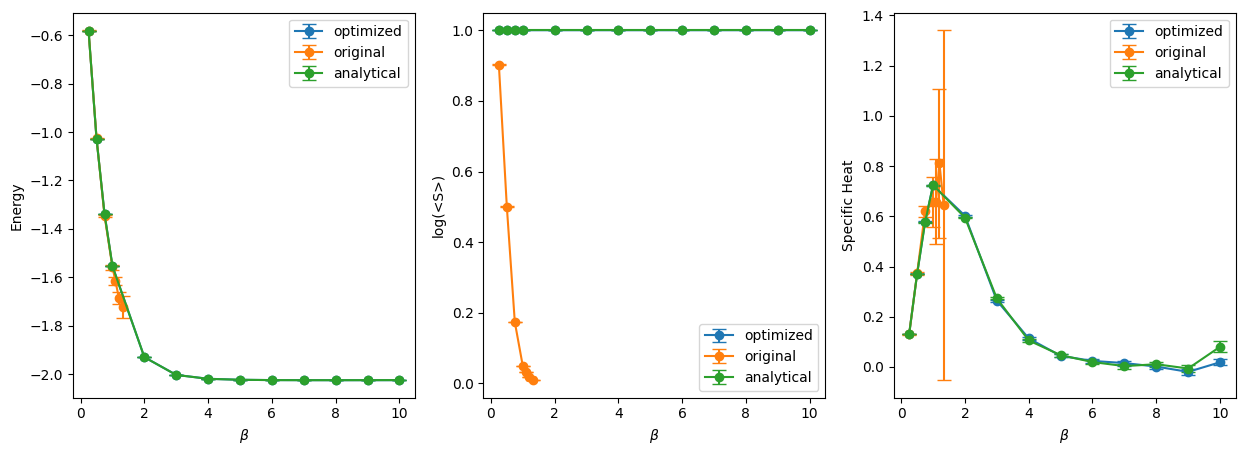

In [15]:
J2 = 3.0
J3 = 2.0

_df = df[(df.J3 == J3) & (df.J2 == J2) & (df["n_sites"] == 10)]

dict_df = {
    "optimized": _df[(_df.u_path.notna()) & (_df.loss_func == "2_mel")].sort_values('as', ascending=False).drop_duplicates(subset=['T']),
    "original": _df[(_df.u_path.isna()) & (_df.loss_func == "2_mel")].sort_values('as', ascending=False).drop_duplicates(subset=['T']),
    "analytical": _df[(_df.u_path.isna()) & (_df.loss_func == "-2_none")].sort_values('as', ascending=False).drop_duplicates(subset=['T']),
}


for key, df_t in dict_df.items():
    mask = (df_t['as'] > 0.005) & (df_t['T'] >= 0.1)
    df_t = df_t[mask]
    # sort by T
    df_t = df_t.sort_values(by='T')
    dict_df[key] = df_t

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))  

label = f"J2={J2}, J3={J3}"

for key, df_t in dict_df.items():
    # Plot with error bars
    ax1.errorbar(1/df_t["T"], df_t["e"], yerr=df_t["e_error"], 
                fmt='o-', capsize=5, label=key)
    ax2.errorbar(1/df_t["T"], df_t["as"], yerr=df_t["as_error"],
                fmt='o-', capsize=5, label=key)
    ax3.errorbar(1/df_t["T"], df_t["c"], yerr=df_t["c_error"],
                fmt='o-', capsize=5, label=key)

ax1.legend()
ax1.set_xlabel("$\\beta$")
ax1.set_ylabel("Energy")

ax2.legend()
ax2.set_xlabel("$\\beta$")
ax2.set_ylabel("log(<S>)")

ax3.legend()
ax3.set_xlabel("$\\beta$")
ax3.set_ylabel("Specific Heat")


Text(0, 0.5, 'Specific Heat')

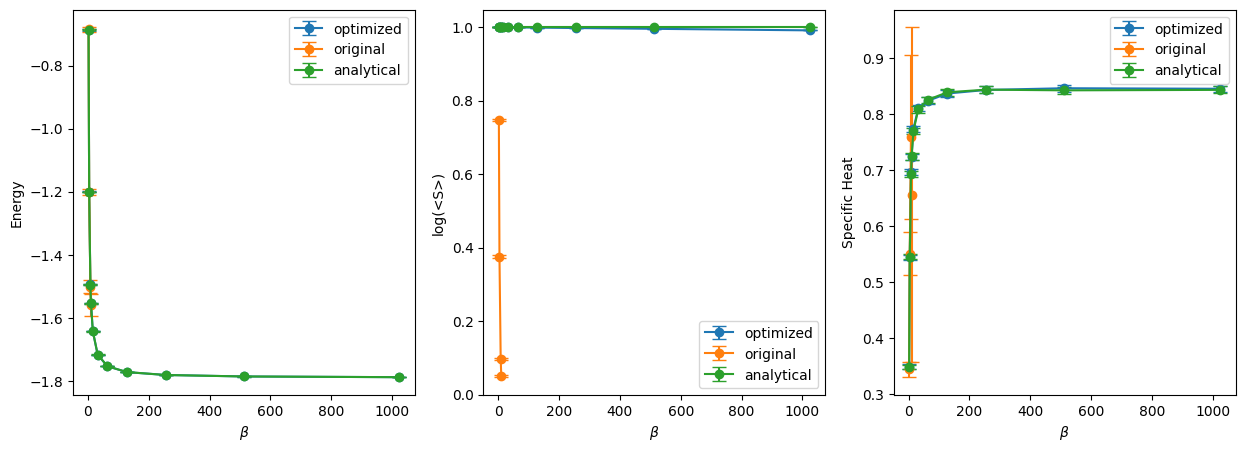

In [10]:
J2 = 3
J3 = 2

_df = df[(df.J3 == J3) & (df.J2 == J2) & (df["T"] == 1)]

dict_df = {
    "optimized": _df[(_df.u_path.notna()) & (_df.loss_func == "2_mel")].drop_duplicates(subset=['n_sites']),
    "original": _df[(_df.u_path.isna()) & (_df.loss_func == "2_mel")].drop_duplicates(subset=['n_sites']),
    "analytical": _df[(_df.u_path.isna()) & (_df.loss_func == "-2_none")].drop_duplicates(subset=['n_sites']),
}


for key, df_t in dict_df.items():
    mask = (df_t['as'] > 0.01)
    df_t = df_t[mask]
    # sort by T
    df_t = df_t.sort_values(by='n_sites')
    dict_df[key] = df_t

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))  

label = f"J2={J2}, J3={J3}"

for key, df_t in dict_df.items():
    # Plot with error bars
    ax1.errorbar(df_t["n_sites"], df_t["e"], yerr=df_t["e_error"] * 3, 
                fmt='o-', capsize=5, label=key)
    ax2.errorbar(df_t["n_sites"], df_t["as"], yerr=df_t["as_error"] * 3,
                fmt='o-', capsize=5, label=key)
    ax3.errorbar(df_t["n_sites"], df_t["c"], yerr=df_t["c_error"] * 3,
                fmt='o-', capsize=5, label=key)

ax1.legend()
ax1.set_xlabel("$\\beta$")
ax1.set_ylabel("Energy")

ax2.legend()
ax2.set_xlabel("$\\beta$")
ax2.set_ylabel("log(<S>)")

ax3.legend()
ax3.set_xlabel("$\\beta$")
ax3.set_ylabel("Specific Heat")


In [14]:
dict_df["optimized"][[ "as", "T" ]]

,as,T
88,0.016703,0.25000
95,0.076645,0.33333
87,0.345206,0.50000
86,0.857421,1.00000
92,0.937928,1.33333
85,0.982435,2.00000
84,0.997986,4.00000


In [54]:
_df_opt.e

0   -0.801577
1   -0.106507
2   -0.207484
3   -0.401704
4   -0.645803
Name: e, dtype: float64

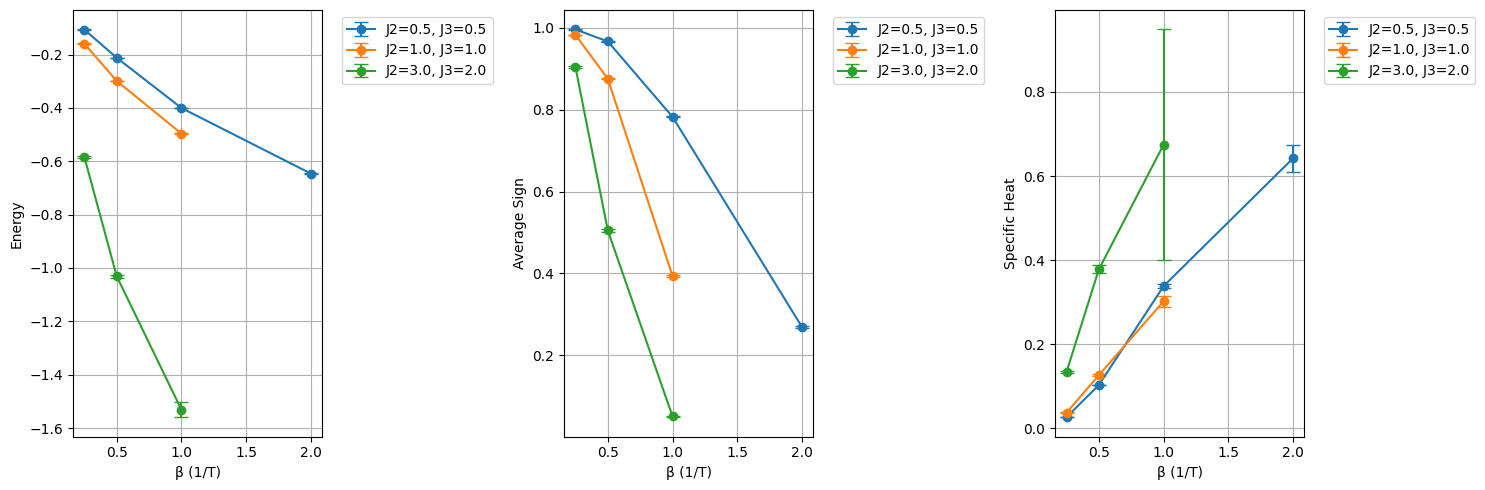

In [8]:
# Create figure with 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))


# Plot for each unique J2, J3 pair
for _, row in unique_pairs.iterrows():
    J2_val = row['J2']
    J3_val = row['J3']
    
    # Filter data for this J2, J3 pair
    _df = df[(df.J3 == J3_val) & (df.J2 == J2_val)]
    df_or = _df[(_df.u_path.isna()) & (_df.loss_func == "2_mel")]
    
    # Filter out points where average sign is too low
    mask = df_or['as'] > 0.05
    
    # Create label for this pair
    label = f'J2={J2_val}, J3={J3_val}'
    
    # Plot energy with error bars (only for points with good average sign)
    ax1.errorbar(1/df_or.loc[mask, 'T'], df_or.loc[mask, 'e'], 
                yerr=df_or.loc[mask, 'e_error'], fmt='o-', capsize=5, label=label)
    
    # Plot average sign with error bars (only for points with good average sign)
    ax2.errorbar(1/df_or.loc[mask, 'T'], df_or.loc[mask, 'as'],
                yerr=df_or.loc[mask, 'as_error'], fmt='o-', capsize=5, label=label)
    
    # Plot specific heat with error bars (only for points with good average sign)
    ax3.errorbar(1/df_or.loc[mask, 'T'], df_or.loc[mask, 'c'],
                yerr=df_or.loc[mask, 'c_error'], fmt='o-', capsize=5, label=label)

# Set labels and properties for all subplots
for ax, ylabel in zip([ax1, ax2, ax3], ['Energy', 'Average Sign', 'Specific Heat']):
    ax.set_xlabel('β (1/T)')
    ax.set_ylabel(ylabel)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True)

plt.tight_layout()
plt.show()


Index(['model_name', 'alpha', 'temperature', 'bc', 'n_sites', 'u_path',
       'ham_path', 'sweeps', 'as', 'as_error', 'e', 'e_error', 'c', 'c_error',
       'm', 'm_error', 'chi', 'chi_error', 'loss_func', 'loss', 'init_loss',
       'J1', 'J2', 'J3'],
      dtype='object')